In [17]:
from utils.analyse_results import GraphsTraining, Results, load_all_pickles, plot_time_bands, plot_time_bands_median, Graphs
import pandas as pd
import numpy as np
import pickle
from pathlib import Path
train_info = GraphsTraining()

In [18]:
pkl_path = Path("results/admm_runs_rl/admm_results_2026-01-11_21-02-28.pkl")
with pkl_path.open("rb") as f:
    data = pickle.load(f)

pkl_path = Path("results/admm_runs_18_01/admm_results_2026-01-18_00-07-07.pkl")
with pkl_path.open("rb") as f:
    data_18_01 = pickle.load(f)

df_singles = pd.read_csv("results/admm_runs_rl/results_nn_pyomo_single.csv")
df_singles_18_01 = pd.read_csv("results/admm_runs_18_01/results_nn_pyomo_single.csv")

In [19]:
#### CAN BE CONVERED INTO A FUNCTION: PYOMO REAL LIFE
fn = "results/admm_rerun/results_full.pkl"
pyomo_convergence = Results.load_results(fn)

keys = {k:k for k in list(pyomo_convergence.values())[0].keys()}
pyomo_df = Results.collect_data(pyomo_convergence, keys)

df = pyomo_df.drop(columns=['result']).reset_index(drop=True)
list_cols = df.columns.tolist()

N_SEEDS = len(df.iloc[0,0])

def seed_labels_chunked(xs, n_seeds):
    L = len(xs)
    n_steps = L // n_seeds
    return list(np.repeat(np.arange(n_seeds), n_steps))

def step_labels_chunked(xs, n_seeds):
    L = len(xs)
    n_steps = L // n_seeds
    return list(np.tile(np.arange(n_steps), n_seeds))

df['seed'] = df[list_cols[0]].apply(lambda xs: seed_labels_chunked(xs, N_SEEDS))

single_long = df.explode(list_cols + ['seed'], ignore_index=True).rename(columns = {"times_elapsed":"time_elapsed", "mse_coll_ode" : "mse_train", "mse_coll_ode_test":"mse_test"})

In [20]:
df = pd.DataFrame(data)
df.head()

df_18_01 = pd.DataFrame(data_18_01)
df_18_01 = df_18_01.T
df_18_01.head()

,primal_residual,mae_collocation,mse_collocation,mae_diffrax,mse_diffrax,iter,time_elapsed,mse_collocation_test
2015-01-15,"[215.40531850554967, 215.40530485964698, 8.750...",[],"[4.239828133047697, 4.239829121896776, 2.05021...",[],"[4.250564180519745, 4.424104823962979, 2.11370...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[33.13462042808533, 34.358760356903076, 39.086...","[5.087412741436122, 5.087414462339645, 5.33990..."
2015-01-20,"[210.81604529189318, 210.81604670538516, 4.849...",[],"[4.829481911496645, 4.8294772382822515, 4.8724...",[],"[16.393425694291913, 17.14530160613246, 22.251...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[27.99281620979309, 29.110186100006104, 35.424...","[12.39746659212361, 12.397479754503145, 12.816..."
2015-01-25,"[235.95522972952836, 235.95522197287514, 6.809...",[],"[5.012156665560832, 5.0121578564463665, 1.8434...",[],"[48.28015352671668, 45.92178701093462, 26.9113...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[25.31655216217041, 26.385462284088135, 31.393...","[11.434030110470166, 11.434028888250253, 10.92..."
2015-01-30,"[212.02135506635025, 212.02135555421307, 4.580...",[],"[3.050985030570114, 3.050985026464072, 3.00138...",[],"[30.086900584758794, 29.704862933159063, 26.17...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[23.94003129005432, 24.978530168533325, 28.852...","[10.166016241948633, 10.166016434704693, 10.00..."
2015-02-04,"[220.84448000206746, 220.84446926882524, 7.632...",[],"[4.01166321782746, 4.0116626909479, 1.50719735...",[],"[3.9869308397555305, 4.053536626393889, 1.4843...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[27.355059385299683, 28.531994581222534, 35.28...","[5.580480598068164, 5.580481209245035, 2.77654..."


In [21]:
df_18_01["seed"] = df_18_01.index.astype(str)


In [22]:
list_cols = [
    "primal_residual",
    "mse_diffrax",
    "iter",
    "time_elapsed",
    "mse_test_diffrax",
    "mse_collocation_train",
    "mse_collocation_test",
]

df_long = (
    df
    .assign(**{c: df[c].apply(list) for c in list_cols})  # in case some are arrays
    .explode(list_cols, ignore_index=True)
)

list_cols = [
    "primal_residual",
    "mse_diffrax",
    "iter",
    "time_elapsed",
    "mse_collocation",
    "mse_collocation_test",
]

df_long_18_01 = (
    df_18_01
    .assign(**{c: df_18_01[c].apply(list) for c in list_cols})  # in case some are arrays
    .explode(list_cols, ignore_index=True)
)


In [23]:
df_singles_18_01 = df_singles_18_01.rename(columns={"times_elapsed": "time_elapsed", "mse_coll_ode": "mse_diffrax", "mse_coll_ode_test": "mse_test_diffrax"})

In [33]:
df_singles_18_01

,regularization,time_elapsed,mse_odeint,mse_diffrax,mse_odeint_test,mse_test_diffrax
0,1,80.190787,205.277844,0.086237,39.294677,0.110151
1,1,80.098166,8.475229,0.017021,13.853389,1.474249
2,1,80.364921,39.344845,0.111310,164.274817,2.611774
3,1,80.359295,816.562773,0.065234,515.022884,0.475477
4,1,80.186264,2682.460593,0.060384,1564.789403,0.076737
5,1,80.249382,3402.281468,0.090872,986.992101,0.123105
6,1,80.381837,0.020916,0.004228,5.114702,5.147990
7,1,80.272185,654.325434,0.110903,279.146359,1.056762
8,1,80.281405,1787.630973,0.046488,585.538945,0.379575
9,1,80.147677,9.785969,0.094968,10.648584,0.870404


In [24]:
single_long = single_long.rename(columns={"mse_test": "mse_test_diffrax", "mse_train":"mse_diffrax"})

In [32]:
df_long_even = df_long[df_long["iter"] % 2 == 0]
df_long_even["iter"] = df_long_even["iter"] + 1
admm_train = Results.prep_for_boxplots(df_long_even,  'iter',  'mse_diffrax')
admm_test = Results.prep_for_boxplots(df_long_even,  'iter',  'mse_test_diffrax')
admm_time = Results.prep_for_boxplots(df_long_even,  'iter',  'time_elapsed')

/var/folders/2v/gfm3z1tn5fj8zss_r9hrgnv80000gn/T/ipykernel_27731/105961478.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_long_even["iter"] = df_long_even["iter"] + 1


In [ ]:
Graphs.plot_single_boxplot(
    admm_test["mse_test_diffrax"],
    admm_test.x_labels,
    title="",
    ylabel="MSE Test",
    color="lightblue",
    x_label="ADMM Iteration",
    y_log=True,
    label_fontsize=20,
    tick_fontsize=18,
    title_fontsize=20,
    grid=True, grid_alpha=0.3, grid_linewidth=0.6, grid_style='--',
    center_line=df_singles_18_01["mse_test_diffrax"].median(),                 # or "median"/"mean"
    center_line_label="Single Models (Median)",
    center_line_color="red",
    center_line_style="--",
    center_line_width=1.2,
    center_legend_bbox_y=-0.08,       # adjust as needed
    center_legend_ncol=1,
    center_legend_fontsize=16,
)

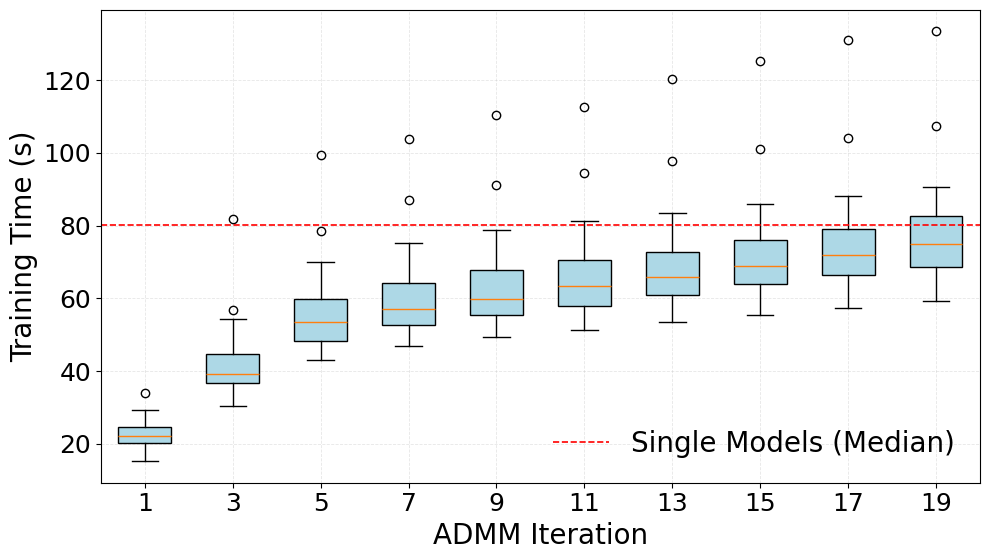

In [40]:
Graphs.plot_single_boxplot(
    admm_time["time_elapsed"],
    admm_time.x_labels,
    title="",
    ylabel="Training Time (s)",
    color="lightblue",
    x_label="ADMM Iteration",
    y_log=False,
    label_fontsize=20,
    tick_fontsize=18,
    title_fontsize=20,
    grid=True, grid_alpha=0.3, grid_linewidth=0.6, grid_style='--',
    center_line=df_singles_18_01["time_elapsed"].median(),                 # or "median"/"mean"
    center_line_label="Single Models (Median)",
    center_line_color="red",
    center_line_style="--",
    center_line_width=1.2,
    center_legend_loc="lower right",
    center_legend_fontsize=20,
)


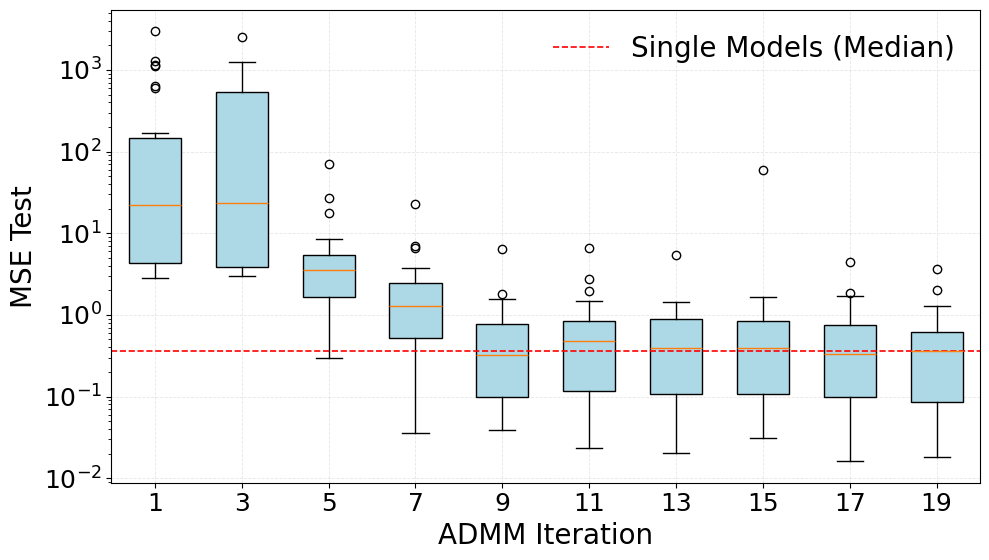

In [39]:
Graphs.plot_single_boxplot(
    admm_test["mse_test_diffrax"],
    admm_test.x_labels,
    title="",
    ylabel="MSE Test",
    color="lightblue",
    x_label="ADMM Iteration",
    y_log=True,
    label_fontsize=20,
    tick_fontsize=18,
    title_fontsize=20,
    grid=True, grid_alpha=0.3, grid_linewidth=0.6, grid_style='--',
    center_line=df_singles_18_01["mse_test_diffrax"].median(),                 # or "median"/"mean"
    center_line_label="Single Models (Median)",
    center_line_color="red",
    center_line_style="--",
    center_line_width=1.2,
    center_legend_loc="upper right",
    center_legend_fontsize=20,
)


/Users/mariiashapo/Library/CloudStorage/OneDrive-Personal/project_2324/NODE/src/utils/analyse_results.py:964: RuntimeWarning: Mean of empty slice
  mean_L = np.nanmean(L, axis=0)
/Users/mariiashapo/anaconda3/envs/node_25/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


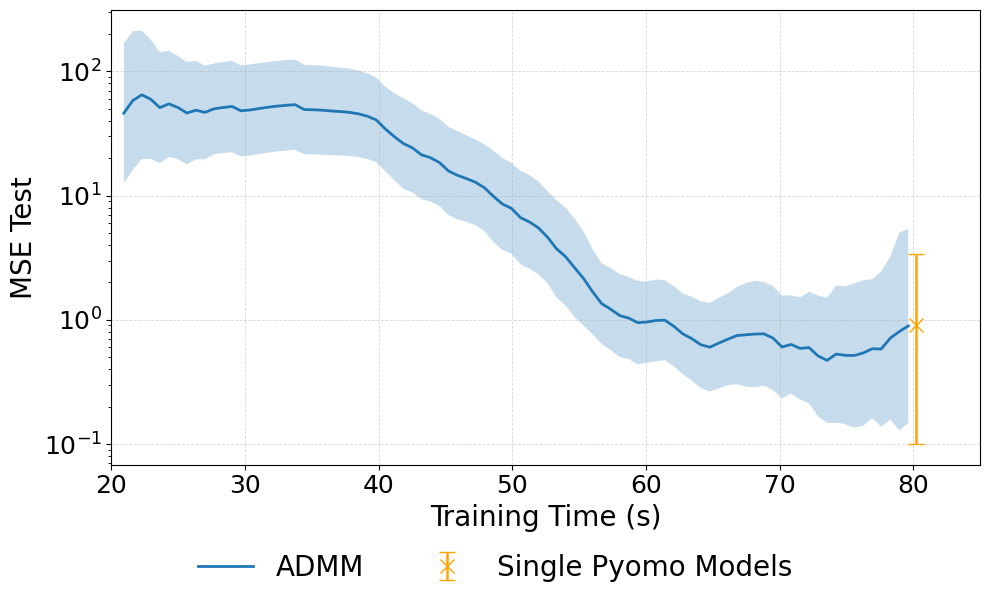

<Axes: xlabel='Training Time (s)', ylabel='MSE Test'>

In [29]:
plot_time_bands(
    {"ADMM": df_long},
    y_col="mse_test_diffrax",
    title="",
    logy=True,
    align_grid=False,
    figsize=(10, 6),
    label_fontsize=20,
    tick_fontsize=18,
    legend_fontsize=20,
    title_fontsize=20,
    tmax_quantile=1,
    xlim=(20, 85),
    legend_bbox_y=-0.02,
    extrapolate=False,
    y_label="MSE Test",
    points_df=df_singles_18_01,
    points_size=100,
    points_label="Single Pyomo Models",
    cutoff_missing_frac=0.7,
    points_errorbar=True,
    points_capsize=6,
    points_center="mean",      # or "mean"
    points_ci=(5, 95),       # percentile CI
)


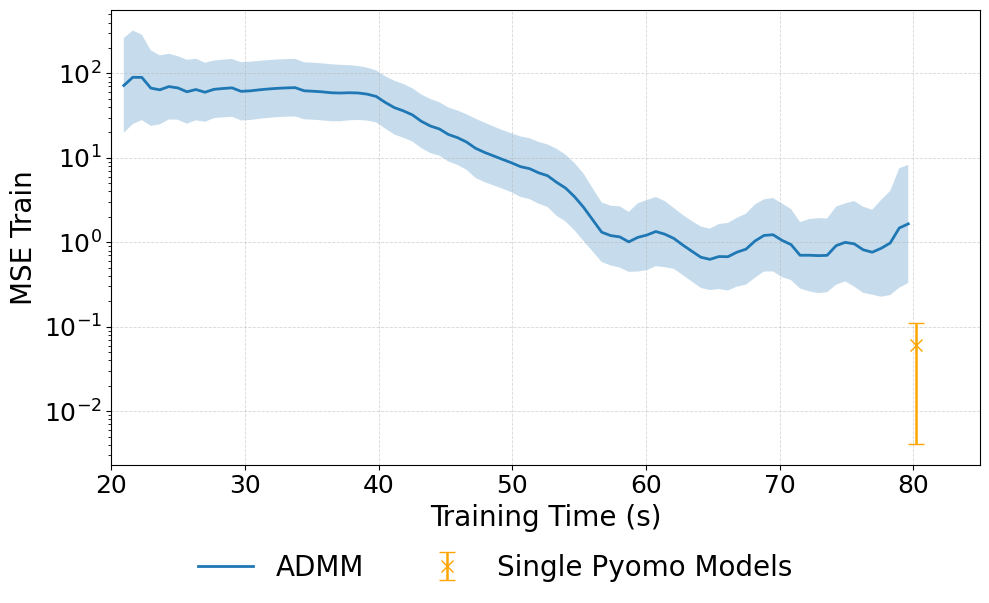

<Axes: xlabel='Training Time (s)', ylabel='MSE Train'>

In [30]:
plot_time_bands(
    {"ADMM":df_long},
    y_col="mse_diffrax",  # or "mse_test"
    title="",
    logy=True,
    align_grid = False,
    figsize=(10, 6),
    label_fontsize=20,
    tick_fontsize=18,
    legend_fontsize=20,
    title_fontsize=20,
    tmax_quantile=1,
    xlim=(20, 85),
    legend_bbox_y=-0.02,
    extrapolate=False,
    y_label="MSE Train",
    points_df=df_singles_18_01, #df_singles_18_01,
    points_size = 80,
    points_label="Single Pyomo Models",
    cutoff_missing_frac=0.7,
    points_errorbar=True,
    points_capsize=6,
    points_center="mean",      # or "mean"
    points_ci=(5, 95),       # percentile CI
)